In [96]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # <- certo

In [97]:
df = pd.read_csv('../data/solar/pvdata.csv', sep = ';')

In [98]:
tf = df.iloc[:,0]
t = pd.to_datetime(tf, format='%d/%m/%Y %H:%M', errors='raise')  # NÃO uses .astype(int)

In [103]:
v = df.iloc[:,2]/1000
a = 18000

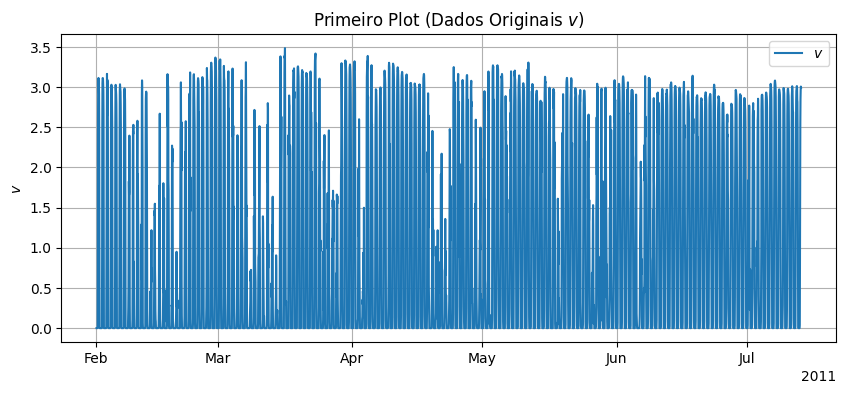

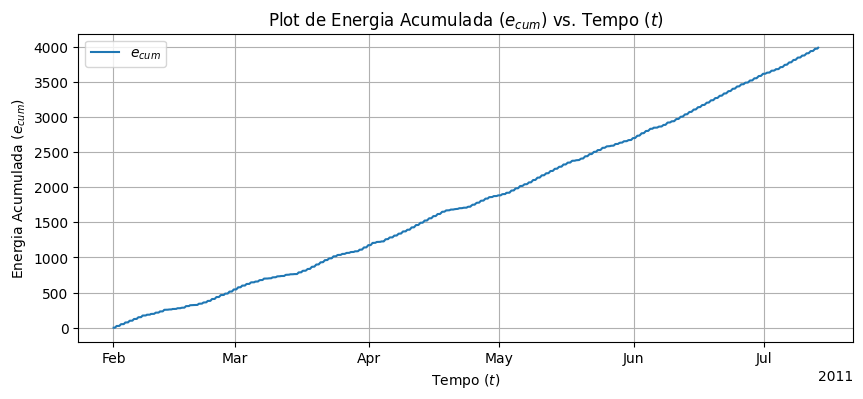

2011-07-13T13:00:00.000000000


In [115]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- pressupõe que t (datas) e v (valores) já existem e têm o mesmo comprimento ---
# Converte para arrays e valida
t = np.asarray(t)
v = np.asarray(v, dtype=float)
assert len(t) == len(v), "t e v devem ter o mesmo comprimento."

# 1) '0000' é inválido em Python 3. Define um corte seguro.
#    Muda 'a' se quiseres plotar só os primeiros N pontos.
a = 3900# por ex., usa a = 500 para ver apenas 500 amostras

# 2) Energia instantânea
e = v  

# 3) Soma cumulativa
#    Se queres que comece em 0 no instante t[0] (mantendo o mesmo comprimento),
#    usa a soma de todos os e até ao índice i-1 e coloca 0 no início:
e_cum = np.concatenate(([0.0], np.cumsum(e[:-1])))

#    (Alternativa: se preferires a cumulativa "clássica", e_cum = np.cumsum(e))

# --- Plot 1: série original ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t[:a], v[:a], label='$v$')
ax.set_title('Primeiro Plot (Dados Originais $v$)')
ax.set_ylabel('$v$')
ax.grid(True)
ax.legend()

# Ticks de data
locator = mdates.AutoDateLocator(maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# --- Plot 2: energia acumulada ---
fig_new, ax_new = plt.subplots(figsize=(10, 4))
ax_new.plot(t[:a], e_cum[:a], label=r'$e_{cum}$')
ax_new.set_title('Plot de Energia Acumulada ($e_{cum}$) vs. Tempo ($t$)')
ax_new.set_xlabel('Tempo ($t$)')
ax_new.set_ylabel('Energia Acumulada ($e_{cum}$)')
ax_new.legend()
ax_new.grid(True)

# Mesma formatação de data
ax_new.xaxis.set_major_locator(locator)
ax_new.xaxis.set_major_formatter(formatter)

plt.show()

print(t[a])


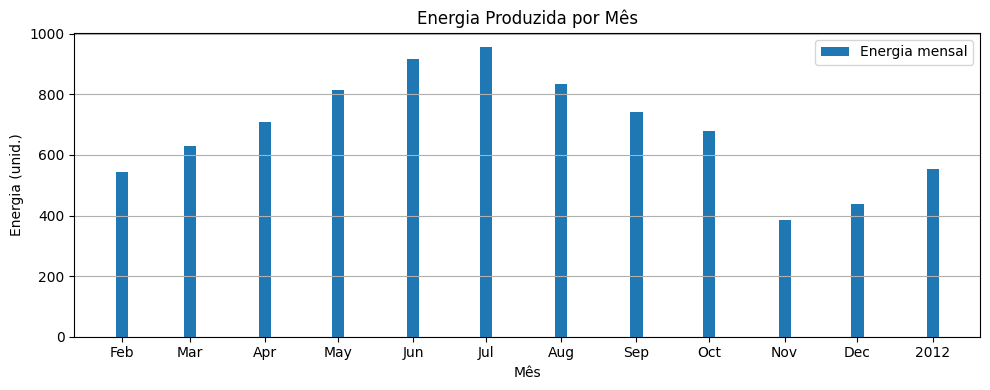

Energia mensal media :  682.9259375
2011-02-01    544.43075
2011-03-01    630.52450
2011-04-01    708.15675
2011-05-01    814.59950
2011-06-01    915.01025
2011-07-01    955.11425
2011-08-01    833.65875
2011-09-01    740.61800
2011-10-01    678.51600
2011-11-01    385.74425
2011-12-01    436.77475
2012-01-01    551.96350
Freq: MS, Name: energia, dtype: float64


In [129]:
t_dt = pd.to_datetime(t)
dt_hours = 1.0  # mude para 0.25 se v for potência com passo de 15 min
# ======================================

# Energia por amostra
e = v * dt_hours

# Série com índice temporal
s = pd.Series(e, index=t_dt).sort_index()

# Agregação mensal (soma da energia no mês)
energia_mensal = s.resample('MS').sum()[:12]

# --- Plot mensal ---
fig, ax = plt.subplots(figsize=(10, 4))

# barras por mês
ax.bar(energia_mensal.index, energia_mensal.values, label='Energia mensal', width=5, )

ax.set_title('Energia Produzida por Mês')
ax.set_xlabel('Mês')
ax.set_ylabel('Energia (unid.)')
ax.grid(True, axis='y')
ax.legend()

# Formatação do eixo de datas (mensal)
locator = mdates.MonthLocator()  # ticks mensais
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

# (Opcional) imprimir tabela mensal
print("Energia mensal media : ",  energia_mensal.values.mean())
print(energia_mensal.rename('energia'))

